# Pretrained atomistic models with `mlcolvar.featurization`

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luigibonati/mlcolvar/blob/main/docs/notebooks/tutorials/adv_featurization.ipynb)

This advanced tutorial shows how to use pretrained atomistic models as frozen
feature extractors for learning collective variables (CVs) with `mlcolvar`.

The atomistic feature-extraction API used here is organized under
`mlcolvar.featurization.atomistic`. Two independent choices define the model:

1. the **atomistic backbone**, which extracts molecular representations;
2. the **CV readout**, which converts those representations into one or more
   collective variables.

The tutorial covers three supported backbones—MACE, PET, and DeePMD-kit—and
three atomistic readout strategies: pooled, node-wise, and selected-atom
concatenation.

**Prerequisites**

- Familiarity with the basic `mlcolvar` tutorials on datasets, CV training,
  and graph-based models.
- Alanine-dipeptide trajectories in `data/alanine_gnn`.
- The optional dependency required by the selected atomistic backend.

**Author:** Kai Zhu

---


### Colab setup

The tutorial is designed primarily for a local development installation because
the supported atomistic backends depend on optional packages such as
`mace-torch`, `metatrain`, `metatomic`, and `deepmd-kit`.

When running in Colab, install the optional dependency corresponding to the
backend selected below.


In [1]:
# Colab setup
import os

if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess

    subprocess.run(
        "wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh",
        shell=True,
        check=True,
    )
    cmd = subprocess.run(
        "bash colab_setup.sh TUTORIAL",
        shell=True,
        check=True,
        stdout=subprocess.PIPE,
    )
    print(cmd.stdout.decode("utf-8"))


## Overview

The downstream workflow is shared by three pretrained atomistic backends:

| Backend | Backbone wrapper | Example model | Optional dependency |
|---|---|---|---|
| MACE | `MACEBackbone` | MACE-MP small | `mace-torch` |
| PET | `PETBackbone` | PET-MAD | `metatrain`, `metatomic`, `metatensor` |
| DeePMD-kit | `DeepMDBackbone` | local DPA-2 checkpoint | `deepmd-kit` with PyTorch support |

The atomistic classes are exposed from:

```python
mlcolvar.featurization.atomistic
```

After constructing an `AtomisticFeaturizer`, `AtomisticModel` converts the
extracted representations into collective variables using one of three readout
modes:

| Mode | Data flow | Main property |
|---|---|---|
| `"pooled"` | node features → pooling → MLP | simple and inexpensive |
| `"nodewise"` | node features → shared MLP → pooling | permutation invariant |
| `"concat"` | selected node features → concatenation → MLP | preserves selected atom identities |

The workflow is:

1. load a pretrained atomistic model;
2. wrap it with a model-specific backbone;
3. construct an `AtomisticFeaturizer`;
4. align the dataset element encoding;
5. construct `AtomisticModel` with the desired readout mode;
6. train the CV;
7. inspect the learned representation;
8. export the trained atomistic model through Metatomic.

> Run the notebook separately for each backend. Restart the kernel before
> changing `BACKBONE_NAME`, because the backends can use different default
> precisions and TorchScript extensions.

## 1. Common architecture

All pretrained atomistic models follow the same layered design:

```text
pretrained atomistic model
            │
            ▼
model-specific backbone
MACEBackbone / PETBackbone / DeepMDBackbone
            │
            │ standardized atom- or system-level features
            ▼
AtomisticFeaturizer
            │
            ▼
AtomisticModel(mode=...)
            │
      ┌─────┼─────┐
      ▼     ▼     ▼
   pooled nodewise concat
            │
            ▼
            CV
```

`mode="pooled"` pools atom-level representations before the trainable readout.
`mode="nodewise"` applies the same readout to every atom and then pools the
atomic outputs, preserving permutation invariance. `mode="concat"` retains the
identity and order of selected atoms, but is not permutation invariant and
therefore requires consistent atom ordering across all systems.

The pretrained backbone can remain frozen while derivatives of the CV with
respect to atomic coordinates are preserved. These derivatives are required
when the learned CV is used to generate enhanced-sampling forces.

## 2. Select the backend, readout, and global settings

Set `BACKBONE_NAME` to `"mace"`, `"pet"`, or `"deepmd"`.

Set `READOUT_NAME` to:

- `"pooled"` to pool atom-level representations before the readout;
- `"nodewise"` to apply a shared readout to each atom before pooling;
- `"concat"` to concatenate selected atom representations before the readout.

All three strategies are implemented by `AtomisticModel`.

MACE with the pooled readout provides the simplest portable example.
The node-wise and concatenation modes require a backbone that returns
atom-level features.

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import torch

torch.manual_seed(41)

# Select one of: "mace", "pet", or "deepmd".
BACKBONE_NAME = "mace"

# Select one of: "pooled", "nodewise", or "concat".
READOUT_NAME = "pooled"

# Used by pooled and node-wise aggregation.
POOLING = "mean"

# Zero-based local atom indices used only with mode="concat".
# These indices select five backbone atoms of alanine dipeptide.
SELECTED_ATOM_INDICES = (4, 6, 8, 14, 16)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = Path("./data/alanine_gnn")

BATCH_SIZE = 32
MAX_EPOCHS = 1

print("Selected backend:", BACKBONE_NAME)
print("Selected readout:", READOUT_NAME)
print("Pooling:", POOLING)
print("Device:", DEVICE)
print("Dataset directory:", DATA_DIR.resolve())

Selected backend: mace
Selected readout: pooled
Pooling: mean
Device: cuda
Dataset directory: /home/kzhu-iit.local/data/mlcolvar-featurizer/docs/notebooks/tutorials/data/alanine_gnn


## 3. Load the pretrained model

This is the only backend-specific section. Each branch creates a standardized
`backbone`, which is then passed to the backend-independent
`AtomisticFeaturizer`.

The example uses `pooling="mean"`. This setting controls aggregation in the
`"pooled"` and `"nodewise"` modes. The `"concat"` mode does not pool features
during its forward pass.

In [3]:
from mlcolvar.featurization.atomistic import AtomisticFeaturizer

BACKBONE_NAME = BACKBONE_NAME.lower()

if BACKBONE_NAME == "mace":
    torch.set_default_dtype(torch.float32)

    from mace.calculators import mace_mp
    from mlcolvar.featurization.atomistic import MACEBackbone

    calculator = mace_mp(
        model="small",
        device=DEVICE,
        default_dtype="float32",
    )
    pretrained_model = calculator.models[0].eval()
    backbone = MACEBackbone(model=pretrained_model)

elif BACKBONE_NAME == "pet":
    torch.set_default_dtype(torch.float64)

    from metatrain.utils.io import load_model
    from mlcolvar.featurization.atomistic import PETBackbone

    PET_MAD_URL = (
        "https://huggingface.co/lab-cosmo/pet-mad/"
        "resolve/v1.0.2/models/pet-mad-v1.0.2.ckpt"
    )

    pretrained_model = load_model(PET_MAD_URL)
    pretrained_model = pretrained_model.to(
        device=DEVICE,
        dtype=torch.float64,
    ).eval()
    backbone = PETBackbone(model=pretrained_model)

elif BACKBONE_NAME == "deepmd":
    torch.set_default_dtype(torch.float32)

    from deepmd.pt.model.model.model import BaseModel
    from deepmd.pt.utils.serialization import serialize_from_file
    from mlcolvar.featurization.atomistic import DeepMDBackbone

    # Set DPA2_MODEL_PATH in the environment or edit the fallback path.
    DPA2_MODEL_PATH = Path(
        os.environ.get(
            "DPA2_MODEL_PATH",
            "./DPA-2.4-7M-SPICE2.pth",
        )
    )

    if not DPA2_MODEL_PATH.exists():
        raise FileNotFoundError(
            "DPA-2 checkpoint not found at "
            f"{DPA2_MODEL_PATH.resolve()}. Set the DPA2_MODEL_PATH "
            "environment variable or edit DPA2_MODEL_PATH."
        )

    serialized_model = serialize_from_file(str(DPA2_MODEL_PATH))
    pretrained_model = BaseModel.deserialize(serialized_model["model"])
    pretrained_model = pretrained_model.to(
        device=DEVICE,
        dtype=torch.float32,
    ).eval()
    backbone = DeepMDBackbone(model=pretrained_model)

else:
    raise ValueError(
        "BACKBONE_NAME must be 'mace', 'pet', or 'deepmd', "
        f"found {BACKBONE_NAME!r}."
    )

featurizer = AtomisticFeaturizer(
    backbone=backbone,
    pooling=POOLING,
    freeze=True,
)

print("Backbone:", type(backbone).__name__)
print("Feature dimension:", backbone.out_features)
print("Sample kind:", backbone.sample_kind)
print("Atomic numbers:", backbone.atomic_numbers.detach().cpu().tolist())
print("Cutoff:", float(backbone.cutoff.detach().cpu().item()))
print("Frozen:", featurizer.freeze)


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/si

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using Materials Project MACE for MACECalculator with /home/kzhu-iit.local/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


Backbone: MACEBackbone
Feature dimension: 256
Sample kind: atom
Atomic numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94]
Cutoff: 6.0
Frozen: True


### Backend-specific notes

#### MACE

`MACEBackbone` extracts the pretrained node representation exposed by MACE.
The MACE-MP **small** model keeps this example relatively lightweight.

#### PET

`PETBackbone` converts the `mlcolvar` graph batch into Metatomic systems and
extracts PET features. PET can use a different internal precision from the
trainable readout; `AtomisticModel` casts the extracted features to the readout precision without
breaking coordinate gradients.

The PET TorchScript compatibility patch must be applied before PET,
metatensor, or metatomic internals are imported. This is handled automatically
by the PET backbone inside `mlcolvar.featurization.atomistic`.

#### DeePMD-kit

`DeepMDBackbone` uses the descriptor of a serialized DeePMD PyTorch model. The
element order is read from the model type map. A local checkpoint must be
provided through `DPA2_MODEL_PATH`.


## 4. Construct the graph dataset

The pretrained model determines the neighbor-list cutoff and required element
table, so the dataset is constructed using the standardized cutoff exposed by
the selected backbone.

MDTraj stores coordinates in nanometers, whereas the pretrained models used
here expect ångström. Therefore, the example uses
`lengths_conversion=10.0`.


In [4]:
from mlcolvar.io import create_dataset_from_trajectories

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {DATA_DIR.resolve()}"
    )

load_args = [
    {"start": 0, "stop": 10000, "stride": 5},
    {"start": 0, "stop": 10000, "stride": 5},
]

model_cutoff = float(featurizer.cutoff.detach().cpu().item())

dataset = create_dataset_from_trajectories(
    trajectories=[
        "alad_A.trr",
        "alad_B.trr",
    ],
    topologies="alad.gro",
    folder=str(DATA_DIR),
    cutoff=model_cutoff,
    system_selection="all",
    show_progress=False,
    load_args=load_args,
    lengths_conversion=10.0,
)

print("Dataset information:")
print(dataset)
print("\nDataset metadata:")
print(dataset.metadata)


/home/kzhu-iit.local/data/mlcolvar-featurizer/mlcolvar/data/graph/utils.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  graph_labels = torch.tensor( config.graph_labels, dtype=torch.get_default_dtype() )   if config.graph_labels is not None else None


Dataset information:
DictDataset( "data_list": 4000,
	    metadata={"atomic_numbers": [1, 6, 7, 8],
		      "cutoff": 6.0,
		      "buffer": 0.0,
		      "long_range_cutoff": -1.0,
		      "system_idx": tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21]),
		      "system_atoms_names": [ACE1-H1, ACE1-CH3, ACE1-H2, ACE1-H3, ACE1-C, ACE1-O, ALA2-N, ALA2-H, ALA2-CA, ALA2-HA, ALA2-CB, ALA2-HB1, ALA2-HB2, ALA2-HB3, ALA2-C, ALA2-O, NME3-N, NME3-H, NME3-C, NME3-H1, NME3-H2, NME3-H3],
		      "is_truncated_graph": False,
		      "data_type": graphs } )

Dataset metadata:
{'atomic_numbers': [1, 6, 7, 8], 'cutoff': 6.0, 'buffer': 0.0, 'long_range_cutoff': -1.0, 'system_idx': tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21]), 'system_atoms_names': [ACE1-H1, ACE1-CH3, ACE1-H2, ACE1-H3, ACE1-C, ACE1-O, ALA2-N, ALA2-H, ALA2-CA, ALA2-HA, ALA2-CB, ALA2-HB1, ALA2-HB2, ALA2-HB3, ALA2-C, ALA2-O, NME

## 5. Align the element encoding

Graph datasets store atomic species in `node_attrs`, usually as one-hot
vectors. Their column order must match the element order expected by the
pretrained model.

For example, a dataset encoded as `[H, O, C, N]` cannot be passed directly to a
model trained with `[H, C, N, O]`, even though both contain the same elements.
`align_dataset()` rebuilds the node attributes in the order required by the
selected backbone.


In [5]:
print(
    "Dataset atomic numbers before alignment:",
    dataset.metadata["atomic_numbers"],
)

dataset = featurizer.align_dataset(dataset)
example_graph = dataset["data_list"][0]

print(
    "Dataset atomic numbers after alignment:",
    dataset.metadata["atomic_numbers"],
)
print("node_attrs shape:", example_graph["node_attrs"].shape)
print("Backbone element count:", backbone.atomic_numbers.numel())

assert (
    example_graph["node_attrs"].shape[-1]
    == backbone.atomic_numbers.numel()
)
assert (
    len(dataset.metadata["atomic_numbers"])
    == backbone.atomic_numbers.numel()
)


Dataset atomic numbers before alignment: [1, 6, 7, 8]
Dataset atomic numbers after alignment: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94]
node_attrs shape: torch.Size([22, 89])
Backbone element count: 89


## 6. Create the data module

`DictModule` batches graph dictionaries while preserving the atomistic
information required by the backbone, including positions, graph assignments,
cells, neighbor lists, and node attributes.


In [6]:
from mlcolvar.data import DictModule

datamodule = DictModule(
    dataset=dataset,
    batch_size=BATCH_SIZE,
)

print("Datamodule information:")
print(datamodule)


Datamodule information:
DictModule(dataset -> DictDataset( "data_list": 4000,
	    metadata={"atomic_numbers": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94],
		      "cutoff": 6.0,
		      "buffer": 0.0,
		      "long_range_cutoff": -1.0,
		      "system_idx": tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21]),
		      "system_atoms_names": [ACE1-H1, ACE1-CH3, ACE1-H2, ACE1-H3, ACE1-C, ACE1-O, ALA2-N, ALA2-H, ALA2-CA, ALA2-HA, ALA2-CB, ALA2-HB1, ALA2-HB2, ALA2-HB3, ALA2-C, ALA2-O, NME3-N, NME3-H, NME3-C, NME3-H1, NME3-H2, NME3-H3],
		      "is_truncated_graph": False,
		      "data_type": graphs } ),
	     train_loader -> DictLoader(len

## 7. Choose a trainable atomistic CV readout

`AtomisticModel` provides three ways to map pretrained atomistic
representations to a CV. The behavior is selected with the `mode` argument.

### Pooled readout

```python
AtomisticModel(
    featurizer=featurizer,
    mode="pooled",
    n_out=1,
    hidden_layers=(32, 32),
)
```

The atomistic features are pooled first, and the resulting system-level vector
is passed to the trainable MLP. This is the simplest and least expensive
strategy.

### Node-wise readout

```python
AtomisticModel(
    featurizer=featurizer,
    mode="nodewise",
    n_out=1,
    hidden_layers=(32, 32),
)
```

The same MLP is applied independently to every atom, and the atomic outputs
are then pooled. Because the readout is shared and the aggregation is
symmetric, this construction remains permutation invariant.

### Selected-atom concatenation

```python
AtomisticModel(
    featurizer=featurizer,
    mode="concat",
    selected_atom_indices=(4, 6, 8, 14, 16),
    n_out=1,
    hidden_layers=(32, 32),
)
```

The features of selected atoms are concatenated in the specified order before
being passed to the MLP. The indices are zero-based and local to each system.
This strategy preserves atom identity, but it is not permutation invariant;
all graphs must therefore use the same atom ordering.

The selected mode is used below as the neural-network component of `DeepTDA`.
The two metastable states are assigned target centers at `-7` and `7`.

In [7]:
from mlcolvar.cvs import DeepTDA
from mlcolvar.featurization.atomistic import AtomisticModel

READOUT_NAME = READOUT_NAME.lower()

atomistic_cv = AtomisticModel(
    featurizer=featurizer,
    mode=READOUT_NAME,
    selected_atom_indices=(
        SELECTED_ATOM_INDICES
        if READOUT_NAME == "concat"
        else None
    ),
    n_out=1,
    hidden_layers=(32, 32),
)

model = DeepTDA(
    n_states=2,
    n_cvs=1,
    target_centers=[-7.0, 7.0],
    target_sigmas=[0.2, 0.2],
    model=atomistic_cv,
)

print("Readout mode:", READOUT_NAME)
if READOUT_NAME == "concat":
    print("Selected atom indices:", SELECTED_ATOM_INDICES)
print(model)

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


Readout mode: pooled
DeepTDA(
  (loss_fn): TDALoss()
  (nn): AtomisticModel(
    (featurizer): AtomisticFeaturizer(
      (backbone): MACEBackbone(
        (model): ScaleShiftMACE(
          (node_embedding): LinearNodeEmbeddingBlock(
            (linear): Linear(89x0e -> 128x0e | 11392 weights)
          )
          (radial_embedding): RadialEmbeddingBlock(
            (bessel_fn): BesselBasis(r_max=6.0, num_basis=10, trainable=False)
            (cutoff_fn): PolynomialCutoff(p=5.0, r_max=6.0)
          )
          (spherical_harmonics): SphericalHarmonics()
          (atomic_energies_fn): AtomicEnergiesBlock(energies=[[-3.6672, -1.3321, -3.4821, -4.7367, -7.7249, -8.4056, -7.3601, -7.2846, -4.8965, 0.0000, -2.7594, -2.8140, -4.8469, -7.6948, -6.9633, -4.6726, -2.8117, -0.0626, -2.6176, -5.3905, -7.8858, -10.2684, -8.6651, -9.2331, -8.3050, -7.0490, -5.5774, -5.1727, -3.2521, -1.2902, -3.5271, -4.7085, -3.9765, -3.8862, -2.5185, 6.7669, -2.5635, -4.9380, -10.1498, -11.8469, -12.1389, 

### Frozen parameters and coordinate gradients

`AtomisticModel` stores the featurizer in `model.nn.featurizer` and the
trainable MLP in `model.nn.readout`.

Setting `freeze=True` disables parameter gradients for the pretrained
backbone, but does not wrap its forward pass in `torch.no_grad()`. Derivatives
of the final CV with respect to atomic coordinates therefore remain available
for enhanced-sampling forces.

In [8]:
backbone_parameters = list(
    model.nn.featurizer.backbone.parameters()
)
readout_parameters = list(
    model.nn.readout.parameters()
)

print(
    "All backbone parameters frozen:",
    all(not parameter.requires_grad for parameter in backbone_parameters),
)
print(
    "All readout parameters trainable:",
    all(parameter.requires_grad for parameter in readout_parameters),
)

n_backbone = sum(
    parameter.numel()
    for parameter in backbone_parameters
)
n_readout = sum(
    parameter.numel()
    for parameter in readout_parameters
)

print("Backbone parameters:", n_backbone)
print("Trainable readout parameters:", n_readout)


All backbone parameters frozen: True
All readout parameters trainable: True
Backbone parameters: 3847696
Trainable readout parameters: 9313


## 8. Train the CV

The number of epochs is intentionally modest to keep the tutorial lightweight.
For production applications, increase `MAX_EPOCHS` and configure appropriate
logging, checkpointing, validation, and early-stopping criteria.

In [9]:
from lightning import Trainer

from mlcolvar.utils.trainer import MetricsCallback

metrics = MetricsCallback()

trainer = Trainer(
    max_epochs=MAX_EPOCHS,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    callbacks=[metrics],
)

trainer.fit(model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:00<00:00,  1.90it/s]

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 2. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 89 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 49: 100%|██████████| 100/100 [00:07<00:00, 12.91it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 100/100 [00:07<00:00, 12.91it/s]


## 9. Inspect the trained CV

First inspect the training and validation losses recorded by
`MetricsCallback`. Then evaluate the learned CV on the train and validation
splits to verify that both states are mapped to the intended target regions.

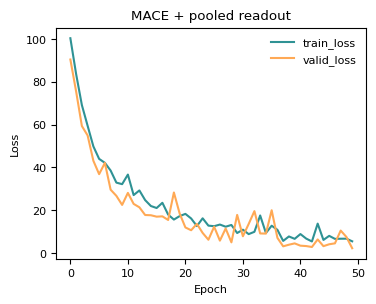

In [10]:
from mlcolvar.utils.plot import plot_metrics

fig, ax = plt.subplots(figsize=(4, 3))

plot_metrics(
    metrics.metrics,
    keys=["train_loss", "valid_loss"],
    colors=["fessa1", "fessa5"],
    yscale="linear",
    ax=ax,
)

ax.set_title(f"{BACKBONE_NAME.upper()} + {READOUT_NAME} readout")
ax.set_xlabel("Epoch")
plt.show()

### CV distributions

Evaluation is performed batch by batch to avoid loading the complete graph
dataset into GPU memory at once. The same bin edges are used in both panels,
and normalized histograms are shown because the train and validation splits
contain different numbers of samples.

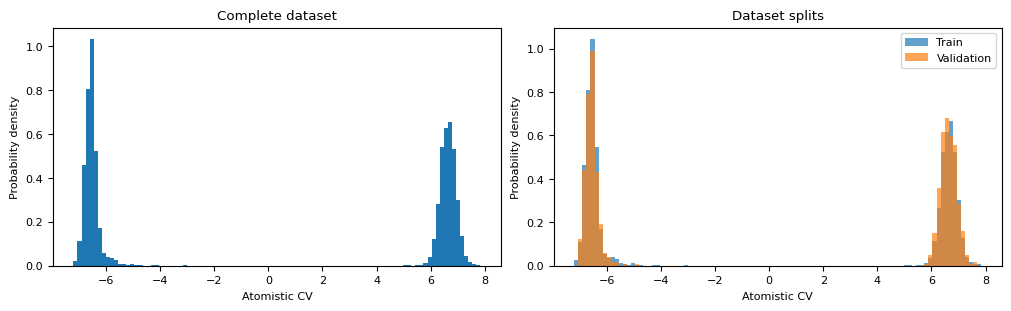

In [11]:
def move_to_device(obj, device):
    """Recursively move tensors in a nested graph batch."""
    if isinstance(obj, torch.Tensor):
        return obj.to(device)

    if isinstance(obj, dict):
        return {
            key: move_to_device(value, device)
            for key, value in obj.items()
        }

    if isinstance(obj, list):
        return [move_to_device(value, device) for value in obj]

    if isinstance(obj, tuple):
        return tuple(move_to_device(value, device) for value in obj)

    return obj


def evaluate_dataloader(model, dataloader):
    """Evaluate a graph CV batch by batch and return a CPU tensor."""
    device = next(model.parameters()).device
    outputs = []

    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            graph_inputs = move_to_device(batch["data_list"], device)
            outputs.append(
                model(graph_inputs).detach().reshape(-1).cpu()
            )

    if not outputs:
        raise RuntimeError("The dataloader did not yield any batches.")

    return torch.cat(outputs)


datamodule.setup()
out_train = evaluate_dataloader(
    model,
    datamodule.train_dataloader(),
)
out_valid = evaluate_dataloader(
    model,
    datamodule.val_dataloader(),
)
out_all = torch.cat((out_train, out_valid))

bin_edges = torch.linspace(
    out_all.min(),
    out_all.max(),
    steps=101,
).numpy()

fig, axs = plt.subplots(
    1,
    2,
    figsize=(10, 3),
    constrained_layout=True,
)

axs[0].hist(
    out_all.numpy(),
    bins=bin_edges,
    density=True,
)
axs[0].set_title("Complete dataset")
axs[0].set_xlabel("Atomistic CV")
axs[0].set_ylabel("Probability density")

axs[1].hist(
    out_train.numpy(),
    bins=bin_edges,
    density=True,
    alpha=0.7,
    label="Train",
)
axs[1].hist(
    out_valid.numpy(),
    bins=bin_edges,
    density=True,
    alpha=0.7,
    label="Validation",
)
axs[1].set_title("Dataset splits")
axs[1].set_xlabel("Atomistic CV")
axs[1].set_ylabel("Probability density")
axs[1].legend()

plt.show()

## 10. Export the trained CV through Metatomic

Metatomic provides a common deployment interface for PLUMED and other
simulation engines. The exporter used here is atomistic-specific and therefore
lives under:

```python
mlcolvar.featurization.atomistic.metatomic
```

It converts Metatomic `System` objects into the graph representation expected
by the atomistic featurizer. It is not currently a generic exporter for
descriptor-based FFNN models.

The exported model contains the inference path in `model.nn`, together with
optional postprocessing, but excludes Lightning training state and `TDALoss`.

```text
Metatomic System objects
    → mlcolvar atomistic graph
    → pretrained backbone
    → pooled, node-wise, or concatenation readout
    → fixed-size "feature" output
```

The exporter preserves the model's current device. The example therefore
declares only the device used and tested in this notebook. Advertise additional
devices only after validating the exported model on them.

For `mode="concat"`, deployment must preserve the atom ordering used during
training.

DeePMD models can require custom TorchScript operators. When requested,
`collect_extensions` creates a deployment directory containing the recorded
extension libraries. Copy this directory together with the exported model.

> For MACE, export from a fresh Python process or kernel and avoid calling
> `torch.jit.script(model.nn)` beforehand, because plain recursive scripting is
> not compatible with all e3nn modules.


In [12]:
from mlcolvar.featurization.atomistic.metatomic import export_metatomic_model

model = model.eval()

atomic_types = [
    int(value)
    for value in backbone.atomic_numbers.detach().cpu().tolist()
]
interaction_range = float(backbone.cutoff.detach().cpu().item())

first_parameter = next(model.nn.parameters(), None)
metatomic_dtype = (
    "float32"
    if first_parameter is not None
    and first_parameter.dtype == torch.float32
    else "float64"
)

METATOMIC_EXPORT_PATH = Path(
    f"deep_tda_{BACKBONE_NAME}_{READOUT_NAME}_metatomic.pt"
)

export_options = {}
if BACKBONE_NAME == "deepmd":
    DEEPMD_EXTENSIONS_DIR = Path("deepmd_extensions")
    export_options["collect_extensions"] = DEEPMD_EXTENSIONS_DIR

export_metatomic_model(
    model=model,
    path=METATOMIC_EXPORT_PATH,
    out_features=model.n_cvs,
    atomic_types=atomic_types,
    interaction_range=interaction_range,
    length_unit="angstrom",
    dtype=metatomic_dtype,
    supported_devices=[DEVICE],
    name=(
        f"mlcolvar DeepTDA with {BACKBONE_NAME} "
        f"and {READOUT_NAME} readout"
    ),
    description=(
        "DeepTDA collective variable using a frozen pretrained "
        f"{BACKBONE_NAME} atomistic representation and "
        f"{READOUT_NAME} readout."
    ),
    **export_options,
)

print("Saved model:", METATOMIC_EXPORT_PATH.resolve())
print("Atomic types:", atomic_types)
print("Interaction range:", interaction_range)
print("Export dtype:", metatomic_dtype)
print("Declared devices:", [DEVICE])

if BACKBONE_NAME == "deepmd":
    print("Collected extensions:", DEEPMD_EXTENSIONS_DIR.resolve())


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


Saved model: /home/kzhu-iit.local/data/mlcolvar-featurizer/docs/notebooks/tutorials/deep_tda_mace_pooled_metatomic.pt
Atomic types: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94]
Interaction range: 6.0
Export dtype: float32
Declared devices: ['cuda']


## 11. Use the exported model in PLUMED

The PLUMED `METATOMIC` action loads the exported model and exposes its
fixed-size `"feature"` output as a collective variable.

Atoms must be grouped by atomic type. `SPECIES_TO_TYPES` contains one type for
each `SPECIES` group, in the same order.

### MACE example

```plumed
MOLINFO STRUCTURE=plumed_topo.pdb PYTHON_BIN=python

h_atoms: GROUP ATOMS={@mdt:{type H}}
c_atoms: GROUP ATOMS={@mdt:{type C}}
n_atoms: GROUP ATOMS={@mdt:{type N}}
o_atoms: GROUP ATOMS={@mdt:{type O}}

gnn: METATOMIC ...
    MODEL=./deep_tda_mace_pooled_metatomic.pt
    DEVICE=cpu
    SPECIES1=h_atoms
    SPECIES2=c_atoms
    SPECIES3=n_atoms
    SPECIES4=o_atoms
    SPECIES_TO_TYPES=1,6,7,8
    CHECK_CONSISTENCY
...

opes: OPES_METAD ...
    ARG=gnn.node-0
    PACE=500
    TEMP=300
    BARRIER=40
...

PRINT ARG=gnn.node-0,opes.* FILE=COLVAR STRIDE=500
```

Update the following system-specific fields:

- `MODEL`: path to the exported model;
- `DEVICE`: `cpu` or `cuda`, depending on the exported model;
- `SPECIES1`, `SPECIES2`, ...: atoms grouped by atomic type;
- `SPECIES_TO_TYPES`: one atomic type for each species group.

For models that use atomic numbers as type identifiers, common values are `1`
for H, `6` for C, `7` for N, and `8` for O.

For a multi-component CV, PLUMED exposes `gnn.node-0`, `gnn.node-1`, and so
on.

### DeePMD extensions

DeePMD models can require custom TorchScript operators. Supply the directory
containing the corresponding shared libraries:

```plumed
gnn: METATOMIC ...
    MODEL=./deep_tda_deepmd_pooled_metatomic.pt
    EXTENSIONS_DIRECTORY=/absolute/path/to/deepmd_extensions
    DEVICE=cpu
    SPECIES1=h_atoms
    SPECIES2=c_atoms
    SPECIES3=n_atoms
    SPECIES4=o_atoms
    SPECIES_TO_TYPES=1,6,7,8
    CHECK_CONSISTENCY
...
```

The extension libraries must be binary-compatible with the PyTorch, CUDA,
compiler runtime, and system libraries available on the deployment machine.
Absolute paths are recommended while debugging deployment.

## 12. Optional direct TorchScript export

A raw TorchScript model can be useful for custom Python or C++ interfaces that
already construct the `mlcolvar` graph dictionary.

This is distinct from Metatomic export:

- raw TorchScript expects `Dict[str, Tensor]`;
- Metatomic accepts `List[System]` and performs input conversion.

Set `RUN_DIRECT_TORCHSCRIPT_EXPORT=True` to enable this optional export. For
MACE, use a fresh kernel if the Metatomic export has already compiled the same
e3nn classes.


In [13]:
RUN_DIRECT_TORCHSCRIPT_EXPORT = False

DIRECT_EXPORT_PATH = Path(
    f"deep_tda_{BACKBONE_NAME}_{READOUT_NAME}_atomistic.pt"
)

if RUN_DIRECT_TORCHSCRIPT_EXPORT:
    inference_model = model.nn.eval()

    if BACKBONE_NAME == "mace":
        from e3nn.util import jit as e3nn_jit

        scripted_model = e3nn_jit.script(
            inference_model,
            in_place=False,
        )
    else:
        scripted_model = torch.jit.script(inference_model)

    torch.jit.save(
        scripted_model,
        str(DIRECT_EXPORT_PATH),
    )

    print(
        "Saved direct TorchScript model:",
        DIRECT_EXPORT_PATH.resolve(),
    )
else:
    print(
        "Direct TorchScript export skipped. "
        "Set RUN_DIRECT_TORCHSCRIPT_EXPORT=True to enable it."
    )


Direct TorchScript export skipped. Set RUN_DIRECT_TORCHSCRIPT_EXPORT=True to enable it.


## 13. Validate the optional direct TorchScript model

When direct export is enabled, compare the serialized model with the original
inference network on one validation graph. This test is not used for the
Metatomic model, whose external input is a list of Metatomic `System` objects.


In [14]:
if RUN_DIRECT_TORCHSCRIPT_EXPORT:
    validation_device = next(model.nn.parameters()).device
    inference_model = model.nn.eval()

    loaded_model = torch.jit.load(
        str(DIRECT_EXPORT_PATH),
        map_location=validation_device,
    ).eval()

    datamodule.setup()
    batch = next(iter(datamodule.val_dataloader()))
    graph = move_to_device(
        batch["data_list"],
        validation_device,
    )

    with torch.no_grad():
        reference = inference_model(graph)
        restored = loaded_model(graph)

    maximum_error = torch.max(
        torch.abs(reference - restored)
    ).item()

    print("Reference shape:", reference.shape)
    print("Restored shape:", restored.shape)
    print("Maximum absolute error:", maximum_error)
else:
    print(
        "Validation skipped because direct export was not enabled."
    )

Validation skipped because direct export was not enabled.


## 14. Summary

The backends differ in how the pretrained model is loaded and how its native
representation is extracted. The downstream featurization, CV construction,
training, and deployment workflow is shared.

| Property | MACE | PET | DeePMD-kit |
|---|---|---|---|
| Adapter | `MACEBackbone` | `PETBackbone` | `DeepMDBackbone` |
| Example model | MACE-MP small | PET-MAD | DPA-2 |
| Model source | automatic download | URL through `metatrain` | local checkpoint |
| Common featurizer | `AtomisticFeaturizer` | `AtomisticFeaturizer` | `AtomisticFeaturizer` |
| Common CV model | `AtomisticModel` | `AtomisticModel` | `AtomisticModel` |
| `mode="pooled"` | supported | supported | supported |
| `mode="nodewise"` | atom-level features required | atom-level features required | atom-level features required |
| `mode="concat"` | fixed atom order required | fixed atom order required | fixed atom order required |
| Coordinate gradients | preserved | preserved | preserved |
| Frozen-backbone mode | supported | supported | supported |
| Metatomic export | supported | supported | requires backend operators |
| PLUMED interface | `METATOMIC` | `METATOMIC` | `METATOMIC` with extensions |

The reusable setup is:

```python
from mlcolvar.featurization.atomistic import AtomisticModel

backbone = ModelSpecificBackbone(model=pretrained_model)

featurizer = AtomisticFeaturizer(
    backbone=backbone,
    pooling="mean",
    freeze=True,
)

graph_model = AtomisticModel(
    featurizer=featurizer,
    mode="pooled",
    n_out=1,
    hidden_layers=(32, 32),
)

cv = DeepTDA(
    n_states=2,
    n_cvs=1,
    target_centers=[-7.0, 7.0],
    target_sigmas=[0.2, 0.2],
    model=graph_model,
)
```

Change `mode` to `"nodewise"` or `"concat"` to use the alternative readout
strategies. For `"concat"`, also provide `selected_atom_indices`.

The reusable deployment pattern is:

```python
export_metatomic_model(
    model=cv.eval(),
    path="cv-metatomic.pt",
    out_features=cv.n_cvs,
    atomic_types=[
        int(value)
        for value in backbone.atomic_numbers.tolist()
    ],
    interaction_range=float(backbone.cutoff),
    length_unit="angstrom",
    dtype="float64",
    supported_devices=[DEVICE],
)
```

This separation keeps optional pretrained-model dependencies inside the
`mlcolvar.featurization.atomistic` package and outside the core CV
implementation, while exposing one common `AtomisticModel` API for readout
selection and a common Metatomic deployment interface for simulation engines
such as PLUMED.